In [ ]:

from tensorflow.keras.datasets import mnist 
(train_images , train_labels) , (test_images,test_labels) = mnist.load_data()



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Dense(512,activation="relu"),
    layers.Dense(10,activation="softmax")
    
])

In [7]:
test_digits = test_images[0:10]
predictions  = model.predict(test_digits)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


In [10]:
predictions[0].argmax()

76

In [13]:

test_loss, test_acc = model.evaluate(test_images, test_labels)

ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 28, 10)

In [ ]:
import tensorflow as tf





/Users/kaisabaab/anaconda3/envs/tf-metal/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [7]:
x = tf.random.normal(shape=(2,1), mean =0 , stddev=1.) 
print(x)

tf.Tensor(
[[-1.0288751 ]
 [ 0.18425979]], shape=(2, 1), dtype=float32)


In [8]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)

print(x)


tf.Tensor(
[[0.5607214 ]
 [0.31109488]
 [0.00165105]], shape=(3, 1), dtype=float32)


In [9]:
x = tf.Variable(initial_value=tf.random.normal(shape = (2,1)))
print(x)

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[-0.3459815],
       [-0.6727484]], dtype=float32)>


In [12]:
x.assign(tf.ones((2,1))) 
print(x)

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>


In [14]:
input_var = tf.Variable(initial_value=3.)

with tf.GradientTape() as tape : 
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)

print(gradient)

tf.Tensor(6.0, shape=(), dtype=float32)


In [16]:
import numpy as np 


num_samples_per_class = 1000

negative_samples = np.random.multivariate_normal(
    mean=[0, 3],
cov=[[1, 0.5],[0.5, 1]],
size=num_samples_per_class)

positive_samples = np.random.multivariate_normal(
mean=[3, 0],
cov=[[1, 0.5],[0.5, 1]],
size=num_samples_per_class)



 

In [18]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

print(inputs)


[[ 1.2993314   3.7013063 ]
 [-0.8822589   0.76821274]
 [-1.5809749   3.6014738 ]
 ...
 [ 3.2093399  -0.04495086]
 [ 4.5376835   1.0295179 ]
 [ 2.0933774  -0.29505327]]


In [20]:
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
np.ones((num_samples_per_class, 1), dtype="float32")))


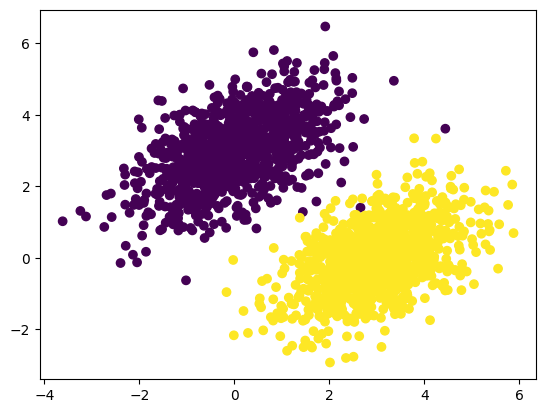

In [22]:
import matplotlib.pyplot as plt
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [23]:
input_dim = 2 
output_dim = 1 

w = tf.Variable(initial_value=tf.random.uniform(shape = (input_dim , output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim)))



In [24]:
#forward pass function
def model(inputs):
    return tf.matmul(inputs, w) + b 

In [28]:
def square_loss(targets,predictions):
    per_sample_loss = tf.square(targets-predictions)
    return tf.reduce_mean(per_sample_loss)
    

In [29]:
learning_rate = 0.1 
def training_step(inputs,targets):
    with tf.GradientTape() as tape : 
        predictions = model(inputs)
        loss = square_loss(predictions,targets)
    grad_loss_wrt_w,grad_loss_wrt_b = tape.gradient(loss,[w,b])
    w.assign_sub(grad_loss_wrt_w*learning_rate)
    b.assign_sub(grad_loss_wrt_b*learning_rate)
    return loss 

In [30]:
for step in range(40):
    loss = training_step(inputs,targets)
    print(f"Loss at step {step}:{loss:.4f}")

    


Loss at step 0:3.3774
Loss at step 1:0.4435
Loss at step 2:0.1660
Loss at step 3:0.1269
Loss at step 4:0.1151
Loss at step 5:0.1069
Loss at step 6:0.0997
Loss at step 7:0.0932
Loss at step 8:0.0873
Loss at step 9:0.0818
Loss at step 10:0.0768
Loss at step 11:0.0723
Loss at step 12:0.0681
Loss at step 13:0.0643
Loss at step 14:0.0608
Loss at step 15:0.0576
Loss at step 16:0.0547
Loss at step 17:0.0520
Loss at step 18:0.0496
Loss at step 19:0.0474
Loss at step 20:0.0453
Loss at step 21:0.0435
Loss at step 22:0.0418
Loss at step 23:0.0402
Loss at step 24:0.0388
Loss at step 25:0.0375
Loss at step 26:0.0363
Loss at step 27:0.0352
Loss at step 28:0.0342
Loss at step 29:0.0333
Loss at step 30:0.0324
Loss at step 31:0.0317
Loss at step 32:0.0310
Loss at step 33:0.0303
Loss at step 34:0.0298
Loss at step 35:0.0292
Loss at step 36:0.0287
Loss at step 37:0.0283
Loss at step 38:0.0279
Loss at step 39:0.0275


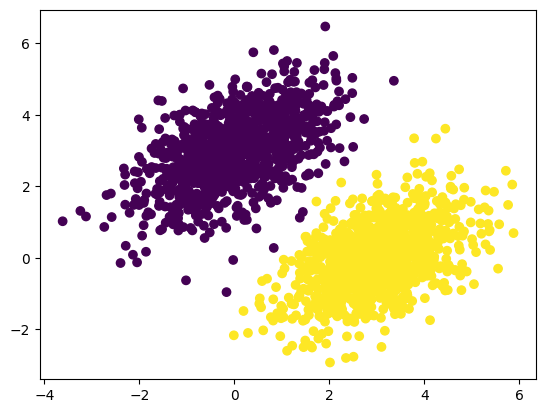

In [31]:
predictions = model(inputs)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

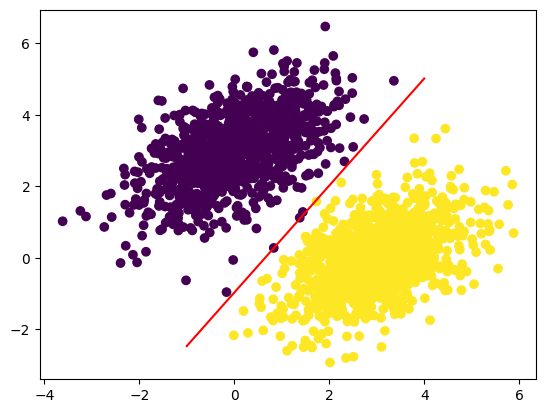

In [35]:
import numpy as np 
x = np.linspace(-1,4,100)
y = - w[0] / w[1] * x + (0.5 - b) / w[1]

plt.plot(x,y,"-r")

plt.scatter(inputs[:,0] , inputs[:,1] , c=predictions[:,0]>0.5)